In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import json

import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 12

In [2]:
base_dir = "../../251029/"
processed_data_dir = base_dir + "science-data_and_code/data/processed_data/"
df_paired_val = pd.read_csv(processed_data_dir + "df_paired_val.csv")
df_paired_learn = pd.read_csv(processed_data_dir + "df_paired_learn.csv")
df_analysis_val = pd.read_csv(processed_data_dir + "df_analysis_val.csv")
df_analysis_learn = pd.read_csv(processed_data_dir + "df_analysis_learn.csv")
df_rounds_learn = pd.read_csv(processed_data_dir + "df_rounds_learn.csv")
df_rounds_val = pd.read_csv(processed_data_dir + "df_rounds_val.csv")
df_predictions = pd.read_csv(processed_data_dir + "prediction_survey.csv").query("prediction.between(-0.2,1.2)")
#df_learning_config = pd.read_csv("../data/exp_config_files/learning.csv")
#df_validation_config = pd.read_csv("../data/exp_config_files/validation.csv")

df_rounds_learn = df_rounds_learn.merge(df_analysis_learn, on="gameId", how="left").query("valid_number_of_starting_players == True").dropna(subset=["data.roundPayoff"]).reset_index(drop=True)
df_rounds_val = df_rounds_val.merge(df_analysis_val, on="gameId", how="left").query("valid_number_of_starting_players == True").dropna(subset=["data.roundPayoff"]).reset_index(drop=True)

In [3]:
df_paired_val["woc_sspp_pred"] = df_paired_val["CONFIG_configId"].map(df_predictions.query("source == 'sspp'").groupby("CONFIG_configId")["prediction"].mean())
df_paired_val["woc_prolific_pred"] = df_paired_val["CONFIG_configId"].map(df_predictions.query("source == 'prolific'").groupby("CONFIG_configId")["prediction"].mean())

In [4]:
def index_of_median_value(s):
    """
    Return the index of the actual data point closest to the median.
    Works for both even and odd-length Series.
    """
    med = s.median()
    return (s - med).abs().idxmin()

In [5]:
ind_median_sspp = index_of_median_value(df_predictions.query("(source == 'sspp') & (n_predictions_made == 20)").groupby('playerID')['squared_error'].mean())
ind_best_sspp = df_predictions.query("(source == 'sspp') & (n_predictions_made == 20)").groupby('playerID')['squared_error'].mean().idxmin()
ind_median_prolific = index_of_median_value(df_predictions.query("(source == 'prolific') & (n_predictions_made == 20)").groupby('playerID')['squared_error'].mean())
ind_best_prolific = df_predictions.query("(source == 'prolific') & (n_predictions_made == 20)").groupby('playerID')['squared_error'].mean().idxmin()

In [6]:
df_pgg = pd.read_csv(base_dir + 'input/pgg_validation_basePrompt.csv')

In [7]:
df_paired_val["median_sspp_pred"] = df_paired_val["CONFIG_configId"].map(
    df_predictions
    .query("playerID == @ind_median_sspp")
    .set_index("CONFIG_configId")["prediction"]
)


df_paired_val["best_sspp_pred"] = df_paired_val["CONFIG_configId"].map(
    df_predictions
    .query("playerID == @ind_best_sspp")
    .set_index("CONFIG_configId")["prediction"]
)

df_paired_val["median_prolific_pred"] = df_paired_val["CONFIG_configId"].map(
    df_predictions
    .query("playerID == @ind_median_prolific")
    .set_index("CONFIG_configId")["prediction"]
)


df_paired_val["best_prolific_pred"] = df_paired_val["CONFIG_configId"].map(
    df_predictions
    .query("playerID == @ind_best_prolific")
    .set_index("CONFIG_configId")["prediction"]
)

In [8]:
df_base_predictions = df_paired_val.set_index("CONFIG_configId")[
    [
    "treatment_itt_efficiency",
    "elastic_prereg_pred",
    "woc_sspp_pred",
    "woc_prolific_pred",
    "median_sspp_pred",
    "best_sspp_pred",
    "median_prolific_pred",
    "best_prolific_pred",
]
].sort_index() * 100

In [9]:
df_base_se = (df_base_predictions.sub(df_base_predictions.treatment_itt_efficiency, axis=0)**2).iloc[:,1:].rename(columns=lambda c: c.replace("_pred", ""))

In [10]:
df_base_se["baseline"] = pd.read_csv(base_dir + 'output/se_baseline_GPT41.csv', index_col=0).values[0]

In [11]:
from matplotlib.lines import Line2D
# --- Shared helpers: config alignment + bootstrap utilities ---

# Map Q1..Q20 columns to CONFIG_configId using the validation prompt file.
config_ids = (
    df_pgg.sort_values("CONFIG_configId")["CONFIG_configId"].tolist()
)

# Canonical config order for all RMSE computations.
base_index = df_base_se.index.tolist()

if base_index != config_ids:
    print(
        "Warning: base_index order differs from CONFIG_configId mapping; "
        "alignment will use base_index."
    )

def align_se_df(df_se, base_index, config_ids, name=""):
    """
    Align SE columns to CONFIG_configId order.

    - If columns are Q1..Q20, map them to config IDs using config_ids.
    - Reindex to base_index to guarantee consistent ordering.
    """
    df = df_se.copy()
    q_cols = [f"Q{i}" for i in range(1, len(config_ids) + 1)]
    if list(df.columns) == q_cols:
        df.columns = config_ids

    # Try to coerce column labels to int for consistent matching.
    try:
        df.columns = df.columns.astype(int)
    except Exception:
        pass

    df = df.reindex(columns=base_index)

    if df.isna().any().any():
        print(f"Warning: {name} has missing values after alignment.")
    return df


def delta_rmse(se_model, se_base):
    """RMSE(model) - RMSE(baseline)."""
    rmse_model = np.sqrt(np.mean(se_model))
    rmse_base = np.sqrt(np.mean(se_base))
    return rmse_model - rmse_base


def bootstrap_delta_rmse(se_model, se_base, n_boot=5000, rng=None):
    """Paired bootstrap over designs to get ΔRMSE + 95% CI."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(se_model)
    boot_vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_vals[b] = delta_rmse(se_model[idx], se_base[idx])
    lo, hi = np.percentile(boot_vals, [2.5, 97.5])
    return boot_vals.mean(), lo, hi


def compute_enet_reference(
    df_base_se,
    baseline_col="baseline",
    enet_col="elastic_prereg",
    n_boot=10000,
    seed=42,
):
    """Bootstrap E-Net ΔRMSE vs baseline using aligned configs."""
    rng = np.random.default_rng(seed)
    se_base = df_base_se[baseline_col].values
    se_enet = df_base_se[enet_col].values
    return bootstrap_delta_rmse(se_enet, se_base, n_boot=n_boot, rng=rng)


def add_enet_reference(ax, enet_ref, color="tab:blue", band_color="tab:blue", band_alpha=0.45):
    """Add E-Net reference line + 95% CI band to a ΔRMSE plot."""
    est, lo, hi = enet_ref
    ax.axhspan(lo, hi, color=band_color, alpha=band_alpha, zorder=0)
    ax.axhline(est, color=color, linestyle=':', linewidth=1.5, zorder=1)
    return Line2D([0], [0], color=color, linestyle=':', linewidth=1.5, label='E-Net from integrative experiments')


# Precompute E-Net reference once for reuse in all ΔRMSE figures.
enet_ref = compute_enet_reference(df_base_se, n_boot=10000, seed=42)


In [12]:
df_laypeople_se = ((df_predictions.query("(source == 'prolific') & (n_predictions_made == 20)").pivot(
    index="CONFIG_configId",
    columns="playerID",
    values="prediction",
)* 100).sub(df_base_predictions.treatment_itt_efficiency, axis=0)**2).T

# Align columns to CONFIG_configId order for safe bootstrapping
df_laypeople_se = align_se_df(df_laypeople_se, base_index, config_ids, name="laypeople")

In [13]:
df_experts_se = ((df_predictions.query("(source == 'sspp') & (n_predictions_made == 20)").pivot(
    index="CONFIG_configId",
    columns="playerID",
    values="prediction",
)* 100).sub(df_base_predictions.treatment_itt_efficiency, axis=0)**2).T

# Align columns to CONFIG_configId order for safe bootstrapping
df_experts_se = align_se_df(df_experts_se, base_index, config_ids, name="experts")

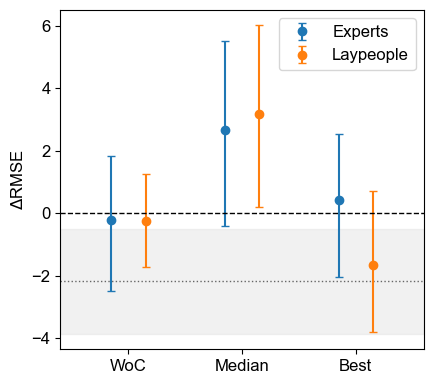

In [14]:
# --- Figure: ΔRMSE by aggregation strategy (WoC / Median / Best) ---

baseline_se = df_base_se.loc[base_index, 'baseline'].values
n_boot = 10000
rng = np.random.default_rng(seed=42)

# Grouping: (experts, laypeople) within each of Wisdom of Crowds / Median / Best
groups = [
    ('woc_sspp',        'woc_prolific',        'WoC'),
    ('median_sspp',     'median_prolific',     'Median'),
    ('best_sspp',       'best_prolific',       'Best'),
]

group_x = np.arange(len(groups))   # 0, 1, 2
offset = 0.15
color_expert = 'tab:blue'
color_lay    = 'tab:orange'

fig, ax = plt.subplots(figsize=(4.5, 4))  # narrower figure

legend_done = {'Experts': False, 'Laypeople': False}

for i, (col_expert, col_lay, group_label) in enumerate(groups):
    # Experts
    se_exp = df_base_se.loc[base_index, col_expert].values
    est_exp, lo_exp, hi_exp = bootstrap_delta_rmse(se_exp, baseline_se, n_boot=n_boot, rng=rng)
    x_exp = group_x[i] - offset
    yerr_exp = [[est_exp - lo_exp], [hi_exp - est_exp]]

    ax.errorbar(
        x_exp, est_exp, yerr=yerr_exp,
        fmt='o', color=color_expert, ecolor=color_expert,
        capsize=3, linestyle='none',
        label='Experts' if not legend_done['Experts'] else None
    )
    legend_done['Experts'] = True

    # Laypeople
    se_lay = df_base_se.loc[base_index, col_lay].values
    est_lay, lo_lay, hi_lay = bootstrap_delta_rmse(se_lay, baseline_se, n_boot=n_boot, rng=rng)
    x_lay = group_x[i] + offset
    yerr_lay = [[est_lay - lo_lay], [hi_lay - est_lay]]

    ax.errorbar(
        x_lay, est_lay, yerr=yerr_lay,
        fmt='o', color=color_lay, ecolor=color_lay,
        capsize=3, linestyle='none',
        label='Laypeople' if not legend_done['Laypeople'] else None
    )
    legend_done['Laypeople'] = True

# Horizontal line at 0 (no difference from baseline)
ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

# E-Net reference line + 95% CI band
enet_handle = add_enet_reference(ax, enet_ref)

# x-ticks at group centers
ax.set_xticks(group_x)
ax.set_xticklabels([g[2] for g in groups], rotation=0, ha='center')

ax.set_ylabel(r'$\Delta$RMSE')

# Make x-range tight around the groups
ax.set_xlim(-0.6, len(groups) - 0.4)

handles, labels = ax.get_legend_handles_labels()
handles.append(enet_handle)
labels.append(enet_handle.get_label())
ax.legend(handles=handles, labels=labels, loc='upper right')

plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_delta_rmse_individuals_simple(
    df_base_se,
    group_to_df,
    baseline_col="baseline",
    n_boot=2000,
    ax=None,
    random_state=42,
    enet_ref=None,
):
    """
    Simple per-forecaster ΔRMSE plot (forecaster − GPT-4.1 baseline).

    Parameters
    ----------
    df_base_se : pd.DataFrame
        Rows = designs; must contain a column `baseline_col`
        with squared errors (SE) for GPT-4.1 for each design.

    group_to_df : dict[str, pd.DataFrame]
        Mapping {group_name -> df_forecaster_se}.
        Each df_forecaster_se has:
          - rows = forecasters in that group
          - columns = designs (aligned with df_base_se rows)
          - values = squared error for that forecaster on that design.

    baseline_col : str
        Name of the baseline SE column in df_base_se.

    n_boot : int
        Number of bootstrap draws per forecaster for CIs.

    ax : matplotlib.axes.Axes or None
        If provided, plot into this axes; otherwise create a new one.

    random_state : int
        Seed for RNG.

    enet_ref : tuple or None
        Precomputed (est, lo, hi) for the E-Net ΔRMSE reference.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    else:
        fig = ax.figure

    rng = np.random.default_rng(random_state)

    # --- baseline SE over designs (aligned to forecaster columns) ---
    design_cols = next(iter(group_to_df.values())).columns
    baseline_se = df_base_se.loc[design_cols, baseline_col].values
    J = len(baseline_se)

    # helper: bootstrap ΔRMSE for one forecaster
    def bootstrap_delta_rmse_single(se_model):
        rmse_model = np.sqrt(np.mean(se_model))
        rmse_base = np.sqrt(np.mean(baseline_se))
        est = rmse_model - rmse_base

        boot_vals = np.empty(n_boot)
        for b in range(n_boot):
            idx = rng.integers(0, J, size=J)
            se_m = se_model[idx]
            se_b = baseline_se[idx]
            rmse_m = np.sqrt(np.mean(se_m))
            rmse_b = np.sqrt(np.mean(se_b))
            boot_vals[b] = rmse_m - rmse_b

        lo, hi = np.percentile(boot_vals, [2.5, 97.5])
        return est, lo, hi

    # --- collect per-forecaster estimates ---
    all_est, all_lo, all_hi, all_group = [], [], [], []

    for group_name, df_se in group_to_df.items():
        se_forecasters = df_se.values  # shape (N_g, J)
        N_g, J_g = se_forecasters.shape
        assert J_g == J, "Design columns must align with df_base_se"

        for i in range(N_g):
            est, lo, hi = bootstrap_delta_rmse_single(se_forecasters[i, :])
            all_est.append(est)
            all_lo.append(lo)
            all_hi.append(hi)
            all_group.append(group_name)

    all_est = np.array(all_est)
    all_lo = np.array(all_lo)
    all_hi = np.array(all_hi)
    all_group = np.array(all_group)

    # significance flags
    sig_better = all_hi < 0
    sig_worse  = all_lo > 0
    sig_none   = ~(sig_better | sig_worse)

    # --- set group order: Experts left, Laypeople right ---
    desired_order = ["Experts", "Laypeople"]
    group_names = [g for g in desired_order if g in group_to_df]
    x_centers = {g: i for i, g in enumerate(group_names)}  # 0, 1, ...

    # jitter within each group
    jitter_width = 0.15
    xs = np.array([
        x_centers[g] + rng.uniform(-jitter_width, jitter_width)
        for g in all_group
    ])

    # --- scatter points (alpha = 0.2) ---
    ax.scatter(xs[sig_none],   all_est[sig_none],
               color='0.7',       alpha=0.2, s=20)
    ax.scatter(xs[sig_better], all_est[sig_better],
               color='tab:green', alpha=0.2, s=25)
    ax.scatter(xs[sig_worse],  all_est[sig_worse],
               color='tab:red',   alpha=0.2, s=25)

    # group medians as black diamonds
    for g, xc in x_centers.items():
        mask = (all_group == g)
        median_est = np.median(all_est[mask])
        ax.scatter(xc, median_est, marker='D',
                   color='black', s=40, zorder=3)

    # baseline line
    ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

    # E-Net reference line + 95% CI band
    if enet_ref is not None:
        enet_handle = add_enet_reference(ax, enet_ref)

    ax.set_ylabel(r'$\Delta$RMSE')

    # --- percentage significantly worse per group ---
    pct_worse_by_group = {}
    for g in group_names:
        mask = (all_group == g)
        if mask.sum() == 0:
            pct_worse_by_group[g] = np.nan
        else:
            frac_worse = sig_worse[mask].sum() / mask.sum()
            pct_worse_by_group[g] = 100 * frac_worse

    # x ticks: group names only
    tick_positions = [x_centers[g] for g in group_names]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(group_names)

    # --- red dot + black text under each group label ---
    # use x-axis transform (x in data coords, y in axes fraction)
    trans = ax.get_xaxis_transform()
    y_text = -0.12  # below the axis; adjust if needed

    for g in group_names:
        pct = pct_worse_by_group[g]
        if np.isnan(pct):
            continue
        xc = x_centers[g]

        # red dot slightly left of centre
        x_dot = xc - 0.18
        # text just to the right of dot
        x_text = xc - 0.14

        ax.scatter(x_dot, y_text, transform=trans,
                   s=12, color='tab:red', clip_on=False)

        ax.text(x_text, y_text,
                f"{pct:.1f}% of individuals",
                color='black',
                ha='left', va='top',
                fontsize='x-small',
                transform=trans)

    # --- legend with solid markers ---
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   label="no significance",
                   markerfacecolor='0.7', markersize=6),
        plt.Line2D([0], [0], marker='o', color='w',
                   label="significantly better than GPT-4.1",
                   markerfacecolor='tab:green', markersize=6),
        plt.Line2D([0], [0], marker='o', color='w',
                   label="significantly worse than GPT-4.1",
                   markerfacecolor='tab:red', markersize=6),
    ]
    if enet_ref is not None:
        legend_handles.append(enet_handle)
    ax.legend(handles=legend_handles, frameon=False,
              fontsize='small', loc='upper left')

    # --- arrow on the right: "better prediction" ---
    fig.subplots_adjust(right=0.88, bottom=0.22)
    x_arrow = 1.02
    y_top, y_bottom = 0.8, 0.2

    ax.annotate(
        '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            color='0.5',
            lw=0.8
        )
    )
    ax.text(
        x_arrow + 0.02,
        (y_top + y_bottom) / 2,
        'better prediction',
        color='0.5',
        rotation=90,
        va='center',
        ha='left',
        fontsize='small',
        transform=ax.transAxes
    )

    return ax


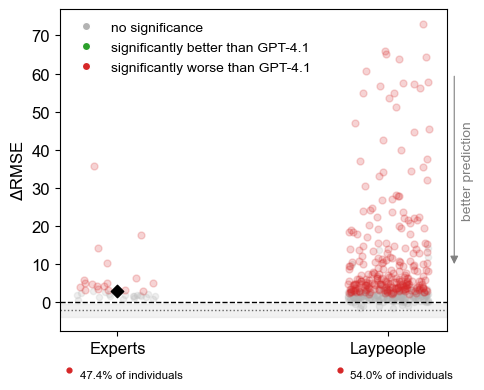

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_delta_rmse_individuals_simple(
    df_base_se,
    {"Laypeople": df_laypeople_se, "Experts": df_experts_se},
    baseline_col="baseline",
    ax=ax,
    n_boot=500,
    enet_ref=enet_ref,
)
plt.tight_layout()
plt.show()


# Fig. 4: Individual and collection RMSE

In [17]:
# --- Full text RMSE SE matrices ---

# Align columns to CONFIG_configId for consistent bootstrapping
df_individual_se = align_se_df(
    pd.read_csv(base_dir + 'output/se_individual_fulltext.csv', index_col=0),
    base_index, config_ids, name='individual_fulltext'
)
df_collection_se = align_se_df(
    pd.read_csv(base_dir + 'output/se_collection_rag.csv', index_col=0),
    base_index, config_ids, name='collection_fulltext'
)
df_all_se = align_se_df(
    pd.read_csv(base_dir + 'output/se_all_rag.csv', index_col=0),
    base_index, config_ids, name='all_fulltext'
)

# include the all-papers aggregate row
df_collection_se = pd.concat([df_collection_se, df_all_se])


In [18]:
# --- Helpers for per-paper ΔRMSE forest plots ---

from matplotlib.lines import Line2D

def compute_paper_deltas(df_base_se, df_individual_se, baseline_col='baseline', n_boot=5000, seed=42):
    """
    Compute per-paper ΔRMSE and 95% CIs using paired bootstrap over designs.
    Assumes df_individual_se columns are aligned to CONFIG_configId order.
    """
    # Align baseline SE to the same config ordering as df_individual_se
    baseline_se = df_base_se.loc[df_individual_se.columns, baseline_col].values
    n_papers = df_individual_se.shape[0]

    rng = np.random.default_rng(seed)
    delta_est = np.empty(n_papers)
    ci_low = np.empty(n_papers)
    ci_high = np.empty(n_papers)

    for i in range(n_papers):
        se_paper = df_individual_se.iloc[i].values
        est, lo, hi = bootstrap_delta_rmse(
            se_paper, baseline_se, n_boot=n_boot, rng=rng
        )
        delta_est[i] = est
        ci_low[i] = lo
        ci_high[i] = hi

    return delta_est, ci_low, ci_high


def random_effects_meta_from_cis(delta_est, ci_low, ci_high):
    """
    Random-effects meta-analysis over papers using per-paper 95% CIs.
    Returns pooled mean + 95% CI and tau^2 (DerSimonian–Laird).
    """
    delta_est = np.asarray(delta_est, dtype=float)
    ci_low = np.asarray(ci_low, dtype=float)
    ci_high = np.asarray(ci_high, dtype=float)

    # Approximate per-paper SE from CI width
    se = (ci_high - ci_low) / (2.0 * 1.96)
    v = se**2

    # Keep only finite, positive-variance papers
    mask = np.isfinite(delta_est) & np.isfinite(v) & (v > 0)
    y = delta_est[mask]
    v = v[mask]

    if len(y) < 2:
        raise ValueError("Not enough valid papers to run random-effects meta-analysis.")

    # Fixed-effect weights
    w = 1.0 / v
    mu_FE = np.sum(w * y) / np.sum(w)

    # DerSimonian–Laird between-paper variance tau^2
    Q = np.sum(w * (y - mu_FE)**2)
    df = len(y) - 1
    c = np.sum(w) - (np.sum(w**2) / np.sum(w))
    if c <= 0:
        tau2 = 0.0
    else:
        tau2 = max(0.0, (Q - df) / c)

    # Random-effects weights
    w_star = 1.0 / (v + tau2)

    # Pooled random-effects estimate
    mu_RE = np.sum(w_star * y) / np.sum(w_star)
    var_mu_RE = 1.0 / np.sum(w_star)
    se_mu_RE = np.sqrt(var_mu_RE)

    # 95% CI (normal approx)
    ci_lo_RE = mu_RE - 1.96 * se_mu_RE
    ci_hi_RE = mu_RE + 1.96 * se_mu_RE

    return mu_RE, ci_lo_RE, ci_hi_RE, tau2


def plot_delta_rmse_forest_from_deltas(delta_est, ci_low, ci_high, ax=None, enet_ref=None):
    """
    Plot per-paper ΔRMSE forest + random-effects pooled mean.
    Expects ΔRMSE and 95% CIs as inputs.
    """
    delta_est = np.asarray(delta_est)
    ci_low = np.asarray(ci_low)
    ci_high = np.asarray(ci_high)

    n_papers = len(delta_est)

    # --- Sort papers by ΔRMSE ---
    order = np.argsort(delta_est)
    delta_sorted = delta_est[order]
    ci_low_sorted = ci_low[order]
    ci_high_sorted = ci_high[order]

    # --- Significance ---
    sig_better = ci_high_sorted < 0
    sig_worse  = ci_low_sorted > 0
    sig_none   = ~(sig_better | sig_worse)

    n_better = int(sig_better.sum())
    n_worse  = int(sig_worse.sum())
    n_none   = int(sig_none.sum())

    pct_better = 100 * n_better / n_papers
    pct_worse  = 100 * n_worse  / n_papers
    pct_none   = 100 * n_none   / n_papers

    # --- Random-effects meta-analysis for pooled mean ---
    summary_est, summary_lo, summary_hi, tau2 = random_effects_meta_from_cis(
        delta_est, ci_low, ci_high
    )

    # --- Plotting ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
    else:
        fig = ax.figure

    x_papers = np.arange(n_papers)

    # Non-significant (grey)
    for x, y, lo, hi in zip(
        x_papers[sig_none],
        delta_sorted[sig_none],
        ci_low_sorted[sig_none],
        ci_high_sorted[sig_none],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='0.7', ecolor='0.7',
            capsize=2, linewidth=0.5, markersize=3,
            alpha=0.2, linestyle='none'
        )

    # Significantly better (green)
    for x, y, lo, hi in zip(
        x_papers[sig_better],
        delta_sorted[sig_better],
        ci_low_sorted[sig_better],
        ci_high_sorted[sig_better],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:green', ecolor='tab:green',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Significantly worse (red)
    for x, y, lo, hi in zip(
        x_papers[sig_worse],
        delta_sorted[sig_worse],
        ci_low_sorted[sig_worse],
        ci_high_sorted[sig_worse],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:red', ecolor='tab:red',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Summary point (meta-analytic pooled mean), solid black
    gap = min(40, int(n_papers * 0.02))  # more space on the right
    x_summary = n_papers + gap
    summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

    ax.errorbar(
        x_summary, summary_est, yerr=summary_yerr,
        fmt='s', color='black', ecolor='black',
        capsize=4, linewidth=1.5, markersize=5,
        linestyle='none'
    )

    # Thicker vertical separator line between individual papers and mean
    x_sep = n_papers
    ax.axvline(x_sep, color='0.6', linestyle='-', linewidth=1.5)

    # Baseline horizontal line
    ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

    # E-Net reference line + 95% CI band
    if enet_ref is not None:
        enet_handle = add_enet_reference(ax, enet_ref)
    else:
        enet_handle = None

    # Axes labels and ticks
    ax.set_ylabel(r'$\Delta$RMSE with 95% CIs')
    ax.set_xlabel("Augmented article (full text)")
    ax.set_xticks([])

    # Expand x-limits a bit to give the mean + arrow more breathing room
    ax.set_xlim(-5, x_summary + gap)

    # --- Legend with only the three significance categories ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly improves prediction (n = {n_better}, {pct_better:.1f}%)',
               markerfacecolor='tab:green', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'No significance (n = {n_none}, {pct_none:.1f}%)',
               markerfacecolor='0.7', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly worsens prediction (n = {n_worse}, {pct_worse:.1f}%)',
               markerfacecolor='tab:red', markersize=5),
    ]
    if enet_handle is not None:
        legend_elements.append(enet_handle)
    ax.legend(handles=legend_elements, loc='upper left',
              frameon=False, fontsize='small')

    # Leave space for arrow and average text on the right
    fig.subplots_adjust(right=0.86)

    # Arrow + label just outside the right axis
    x_arrow = 1.02  # slightly to the right of the frame
    y_top, y_bottom = 0.8, 0.2

    ax.annotate(
        '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            color='0.5',
            lw=0.8
        )
    )

    ax.text(
        x_arrow + 0.02, (y_top + y_bottom) / 2,
        'better prediction',
        color='0.5',
        rotation=90,
        va='center',
        ha='left',
        fontsize='small',
        transform=ax.transAxes
    )

    # --- Rotated text label next to the average point ---
    mean_str = f"{summary_est:.2f}"
    ci_lo_str = f"{summary_lo:.2f}"
    ci_hi_str = f"{summary_hi:.2f}"
    avg_text = f"Average: {mean_str} ({ci_lo_str} to {ci_hi_str})"

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x_text = x_sep + gap
    y_text = ymax - 0.5

    ax.text(
        x_text, y_text,
        avg_text,
        rotation=90,
        va='top',
        ha='center',
        fontsize='x-small'
    )

    return ax


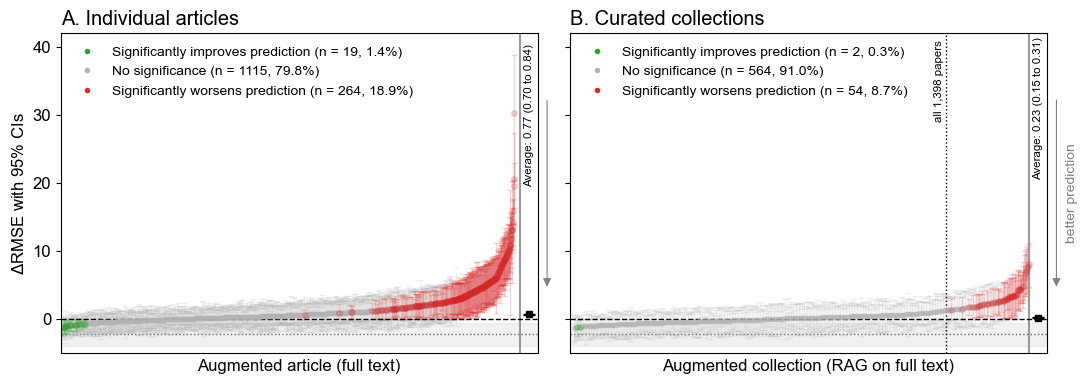

In [23]:
from matplotlib.patches import FancyArrowPatch

# 1) Compute per-predictor ΔRMSE and CIs
delta_art, ci_lo_art, ci_hi_art = compute_paper_deltas(
    df_base_se, df_individual_se,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

delta_coll, ci_lo_coll, ci_hi_coll = compute_paper_deltas(
    df_base_se, df_collection_se,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

# 2) Two subplots side by side with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

# ----- Left: individual articles -----
ax1 = axes[0]
plot_delta_rmse_forest_from_deltas(delta_art, ci_lo_art, ci_hi_art, ax=ax1, enet_ref=enet_ref)
ax1.set_ylim(-5, 42)
ax1.set_title("A. Individual articles", loc="left")

# Remove the arrow + "better prediction" label from the left panel
for txt in list(ax1.texts):
    if txt.get_text() == 'better prediction':
        txt.remove()

for patch in list(ax1.patches):
    if isinstance(patch, FancyArrowPatch):
        patch.remove()

# Keep y-label on the left as is
ax1.set_xlabel("Augmented article (full text)")

# ----- Right: curated collections -----
ax2 = axes[1]
plot_delta_rmse_forest_from_deltas(delta_coll, ci_lo_coll, ci_hi_coll, ax=ax2, enet_ref=enet_ref)
ax2.set_ylim(-5, 42)
ax2.set_title("B. Curated collections", loc='left')
ax2.set_ylabel('')  # keep y-label only on left
ax2.set_xlabel("Augmented collection (RAG)")

# === Highlight the 'ALL' collection ===
# Find its original row index in df_collection_se
all_idx = df_collection_se.index.get_loc('ALL')

# Find its x-position after sorting by ΔRMSE (same sort as inside the plot function)
order_coll = np.argsort(delta_coll)
x_all = np.where(order_coll == all_idx)[0][0]

# Vertical line at that x, plus a small rotated label
ax2.axvline(x_all, color='black', linestyle=':', linewidth=1)

ymin, ymax = ax2.get_ylim()
ax2.text(
    x_all - 10,
    ymax - 1,                     # just below the top
    'all 1,398 papers',
    rotation=90,
    va='top',
    ha='center',
    fontsize='x-small'
)

# Share y-axis: remove duplicate y-label on the right
ax2.set_ylabel('')
ax2.set_xlabel("Augmented collection (RAG on full text)")

plt.tight_layout()
plt.show()

# Abstract instead of full text

In [24]:
# --- Abstract RMSE SE matrices ---

# Align columns to CONFIG_configId for consistent bootstrapping
df_individual_se = align_se_df(
    pd.read_csv(base_dir + 'output/se_individual_abstract.csv', index_col=0),
    base_index, config_ids, name='individual_abstract'
)
df_collection_se = align_se_df(
    pd.read_csv(base_dir + 'output/se_collection_abstract.csv', index_col=0),
    base_index, config_ids, name='collection_abstract'
)
df_all_se = align_se_df(
    pd.read_csv(base_dir + 'output/se_all_abstract.csv', index_col=0),
    base_index, config_ids, name='all_abstract'
)

# include the all-papers aggregate row
df_collection_se = pd.concat([df_collection_se, df_all_se])


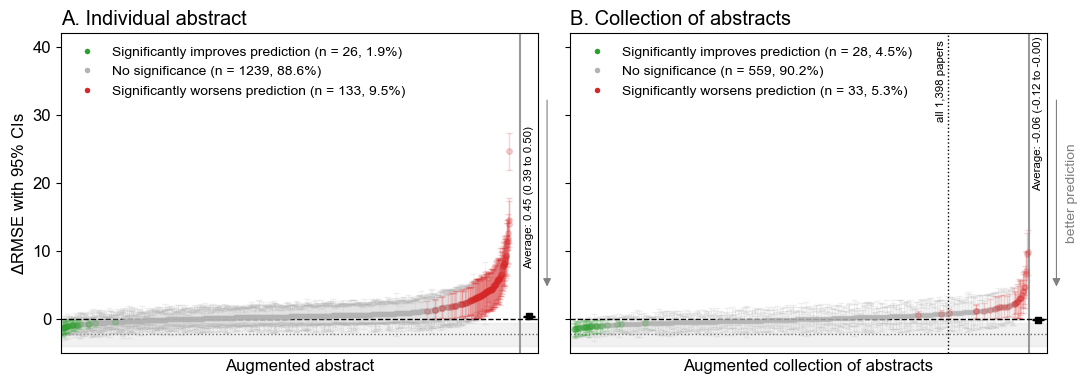

In [25]:
from matplotlib.patches import FancyArrowPatch

# 1) Compute per-predictor ΔRMSE and CIs
delta_art, ci_lo_art, ci_hi_art = compute_paper_deltas(
    df_base_se, df_individual_se,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

delta_coll, ci_lo_coll, ci_hi_coll = compute_paper_deltas(
    df_base_se, df_collection_se,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

# 2) Two subplots side by side with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

# ----- Left: individual articles -----
ax1 = axes[0]
plot_delta_rmse_forest_from_deltas(delta_art, ci_lo_art, ci_hi_art, ax=ax1, enet_ref=enet_ref)
ax1.set_ylim(-5, 42)
ax1.set_title("A. Individual abstract", loc="left")

# Remove the arrow + "better prediction" label from the left panel
for txt in list(ax1.texts):
    if txt.get_text() == 'better prediction':
        txt.remove()

for patch in list(ax1.patches):
    if isinstance(patch, FancyArrowPatch):
        patch.remove()

# Keep y-label on the left as is
ax1.set_xlabel("Augmented abstract")

# ----- Right: curated collections -----
ax2 = axes[1]
plot_delta_rmse_forest_from_deltas(delta_coll, ci_lo_coll, ci_hi_coll, ax=ax2, enet_ref=enet_ref)
ax2.set_ylim(-5, 42)
ax2.set_title("B. Collection of abstracts", loc='left')
ax2.set_ylabel('')  # keep y-label only on left
ax2.set_xlabel("Augmented collection of abstracts")

# === Highlight the 'ALL' collection ===
# Find its original row index in df_collection_se
all_idx = df_collection_se.index.get_loc('ALL')

# Find its x-position after sorting by ΔRMSE (same sort as inside the plot function)
order_coll = np.argsort(delta_coll)
x_all = np.where(order_coll == all_idx)[0][0]

# Vertical line at that x, plus a small rotated label
ax2.axvline(x_all, color='black', linestyle=':', linewidth=1)

ymin, ymax = ax2.get_ylim()
ax2.text(
    x_all - 10,
    ymax - 1,                     # just below the top
    'all 1,398 papers',
    rotation=90,
    va='top',
    ha='center',
    fontsize='x-small'
)

# Share y-axis: remove duplicate y-label on the right
ax2.set_ylabel('')
ax2.set_xlabel("Augmented collection of abstracts")

plt.tight_layout()
plt.show()

# RMSE of LLM summary

In [26]:
# --- LLM summary RMSE SE matrices ---

# Align columns to CONFIG_configId for consistent bootstrapping
df_individual_se = align_se_df(
    pd.read_csv(base_dir + 'output/se_individual_report.csv', index_col=0),
    base_index, config_ids, name='individual_report'
)
df_collection_se = align_se_df(
    pd.read_csv(base_dir + 'output/se_collection_report.csv', index_col=0),
    base_index, config_ids, name='collection_report'
)
df_all_se = align_se_df(
    pd.read_csv(base_dir + 'output/se_all_report.csv', index_col=0),
    base_index, config_ids, name='all_report'
)

# For consistency with the plots, label the aggregate row
if len(df_all_se.index) == 1:
    df_all_se.index = ['ALL']

# include the all-papers aggregate row
df_collection_se = pd.concat([df_collection_se, df_all_se])


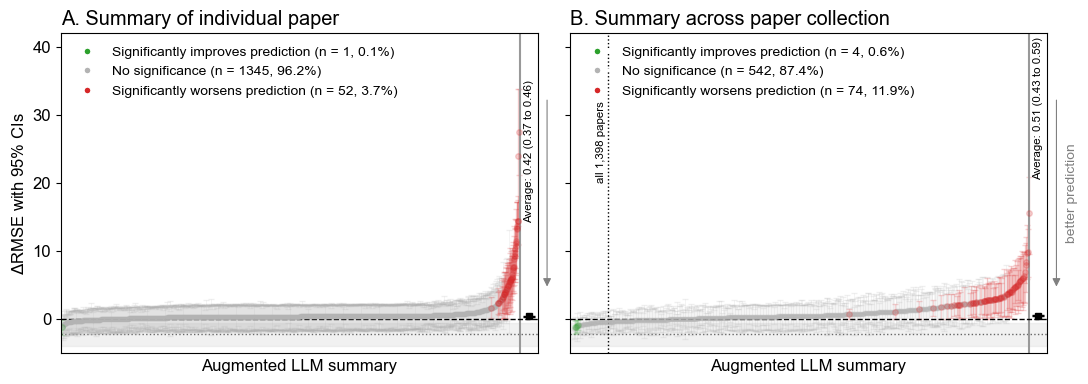

In [27]:
from matplotlib.patches import FancyArrowPatch

# 1) Compute per-predictor ΔRMSE and CIs
delta_art, ci_lo_art, ci_hi_art = compute_paper_deltas(
    df_base_se, df_individual_se,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

delta_coll, ci_lo_coll, ci_hi_coll = compute_paper_deltas(
    df_base_se, df_collection_se,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

# 2) Two subplots side by side with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

# ----- Left: individual articles -----
ax1 = axes[0]
plot_delta_rmse_forest_from_deltas(delta_art, ci_lo_art, ci_hi_art, ax=ax1, enet_ref=enet_ref)
ax1.set_ylim(-5, 42)
ax1.set_title("A. Summary of individual paper", loc="left")

# Remove the arrow + "better prediction" label from the left panel
for txt in list(ax1.texts):
    if txt.get_text() == 'better prediction':
        txt.remove()

for patch in list(ax1.patches):
    if isinstance(patch, FancyArrowPatch):
        patch.remove()

# Keep y-label on the left as is
ax1.set_xlabel("Augmented LLM summary")

# ----- Right: curated collections -----
ax2 = axes[1]
plot_delta_rmse_forest_from_deltas(delta_coll, ci_lo_coll, ci_hi_coll, ax=ax2, enet_ref=enet_ref)
ax2.set_ylim(-5, 42)
ax2.set_title("B. Summary across paper collection", loc='left')
ax2.set_ylabel('')  # keep y-label only on left
ax2.set_xlabel("Augmented collection of abstracts")

# === Highlight the 'ALL' collection ===
# Find its original row index in df_collection_se
all_idx = df_collection_se.index.get_loc('ALL')

# Find its x-position after sorting by ΔRMSE (same sort as inside the plot function)
order_coll = np.argsort(delta_coll)
x_all = np.where(order_coll == all_idx)[0][0]

# Vertical line at that x, plus a small rotated label
ax2.axvline(x_all, color='black', linestyle=':', linewidth=1)

ymin, ymax = ax2.get_ylim()
ax2.text(
    x_all - 10,
    ymax - 10,                     # just below the top
    'all 1,398 papers',
    rotation=90,
    va='top',
    ha='center',
    fontsize='x-small'
)

# Share y-axis: remove duplicate y-label on the right
ax2.set_ylabel('')
ax2.set_xlabel("Augmented LLM summary")

plt.tight_layout()
plt.show()

## Perplexity

In [28]:
# --- Perplexity: full text ---

df_base_ppl = pd.read_csv(base_dir + 'output/perplexity_baseline_GPT41.csv')
# Align Q1..Q20 to CONFIG_configId
df_base_ppl = align_se_df(df_base_ppl, base_index, config_ids, name='ppl_baseline_fulltext')
df_base_ppl.index = ['baseline']

df_individual_ppl = align_se_df(
    pd.read_csv(base_dir + 'output/perplexity_individual_fulltext.csv', index_col=0),
    base_index, config_ids, name='ppl_individual_fulltext'
)
df_collection_ppl = align_se_df(
    pd.read_csv(base_dir + 'output/perplexity_collection_rag.csv', index_col=0),
    base_index, config_ids, name='ppl_collection_fulltext'
)

df_all_ppl = align_se_df(
    pd.read_csv(base_dir + 'output/perplexity_all_rag.csv', index_col=0),
    base_index, config_ids, name='ppl_all_fulltext'
)

# include the all-papers aggregate row
df_collection_ppl = pd.concat([df_collection_ppl, df_all_ppl])


In [29]:
df_collection_ppl

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
DV:Y | Type:E | JIF:Y | Citation:Y | Y16:Any | Discipline:Any | Var:2+,8.315399,8.999554,8.651821,5.001243,4.868039,3.970296,6.777074,3.798696,7.144037,6.838144,4.892482,4.817844,6.242346,6.876051,5.338960,10.362084,4.629907,4.796789,7.243956,6.617002
DV:Y | Type:Any | JIF:Any | Citation:Any | Y16:Y | Discipline:Multi | Var:Any,6.917933,7.674215,5.161951,8.720757,3.650276,3.265395,5.497249,3.424140,8.492697,7.568912,6.359831,3.259794,5.550812,5.077363,5.292133,4.638023,3.477136,6.856641,7.207683,5.568434
DV:Any | Type:R | JIF:Any | Citation:Any | Y16:N | Discipline:Social | Var:0,8.650900,3.761345,4.614372,7.236842,8.077050,1.307155,7.985482,1.339464,7.449898,8.476788,4.225566,1.303137,6.431910,1.125071,2.484328,8.245251,1.011689,9.395633,9.783829,5.175473
DV:N | Type:Any | JIF:N | Citation:N | Y16:Y | Discipline:Econ | Var:Any,7.434274,7.253500,11.850951,5.857134,6.615344,2.579994,8.811269,3.721184,3.123045,7.596558,5.918261,4.629802,9.767831,4.950804,3.178818,7.390777,3.834181,9.535668,8.393902,6.607812
DV:Y | Type:T | JIF:Any | Citation:Any | Y16:Any | Discipline:Math | Var:1,6.177493,6.836422,7.137123,6.831778,5.787295,1.281226,6.051115,1.947541,4.780574,7.518207,2.917152,1.769497,6.127679,4.610669,1.662716,10.294607,3.523137,5.729619,7.655746,3.576250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DV:N | Type:Any | JIF:Y | Citation:N | Y16:Any | Discipline:Psych | Var:0,7.271337,4.988312,5.725770,6.064274,4.556078,3.642529,5.016671,3.821975,4.519303,4.886379,4.616308,4.795650,6.057257,3.256387,3.257615,5.927597,3.078092,5.320756,6.579342,5.621888
DV:N | Type:T | JIF:Y | Citation:Y | Y16:Any | Discipline:Social | Var:2+,5.909883,4.970155,5.142366,5.146335,4.214505,1.949857,5.757824,2.790422,2.873557,1.199282,2.105155,2.807123,5.506092,1.394900,3.389017,3.925595,2.540234,8.049483,6.340629,6.734475
DV:Any | Type:E | JIF:N | Citation:Y | Y16:N | Discipline:Econ | Var:1,1.338298,3.271314,1.005280,5.163488,2.557230,1.014392,2.454142,3.346361,2.770458,1.367924,3.476276,5.904686,5.593029,4.513706,1.846792,2.202814,3.074806,3.094369,4.363671,1.361716
DV:Any | Type:R | JIF:Y | Citation:N | Y16:Any | Discipline:Any | Var:Any,6.122081,5.625610,5.385172,5.992789,4.990930,2.674215,5.978388,3.303395,5.687674,6.088455,5.120129,4.802879,4.882328,4.955164,3.400042,5.592834,3.027813,5.464470,6.624176,3.862972


In [30]:
df_base_ppl.isna().sum().sum()

0

In [31]:
df_base_ppl

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
baseline,9.317094,8.256304,10.433405,9.153496,4.949281,4.803311,8.929935,6.09483,7.040299,8.684772,9.471959,7.371312,9.820434,9.25316,4.933039,9.723615,7.678851,10.591426,9.953723,8.273895


In [32]:
df_base_ppl.index = ['baseline']

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_delta_ppl_forest(delta_est, ci_low, ci_high, ax=None):
    """
    Plot per-paper ΔPerplexity forest + random-effects pooled mean.

    Parameters
    ----------
    delta_est, ci_low, ci_high : np.ndarray
        Per-paper ΔPerplexity and 95% CIs (from compute_paper_deltas).

    ax : matplotlib.axes.Axes or None
        If provided, draw on this axes. Otherwise create a new one.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes containing the plot.
    """
    delta_est = np.asarray(delta_est)
    ci_low = np.asarray(ci_low)
    ci_high = np.asarray(ci_high)

    n_papers = len(delta_est)

    # --- Sort papers by ΔRMSE ---
    order = np.argsort(delta_est)
    delta_sorted = delta_est[order]
    ci_low_sorted = ci_low[order]
    ci_high_sorted = ci_high[order]

    # --- Significance ---
    sig_better = ci_high_sorted < 0
    sig_worse  = ci_low_sorted > 0
    sig_none   = ~(sig_better | sig_worse)

    n_better = int(sig_better.sum())
    n_worse  = int(sig_worse.sum())
    n_none   = int(sig_none.sum())

    pct_better = 100 * n_better / n_papers
    pct_worse  = 100 * n_worse  / n_papers
    pct_none   = 100 * n_none   / n_papers

    # --- Random-effects meta-analysis for pooled mean ---
    def random_effects_meta_from_cis(delta_est, ci_low, ci_high):
        delta_est = np.asarray(delta_est, dtype=float)
        ci_low = np.asarray(ci_low, dtype=float)
        ci_high = np.asarray(ci_high, dtype=float)

        # Approximate SE from 95% CI width
        se = (ci_high - ci_low) / (2.0 * 1.96)
        v = se**2

        mask = np.isfinite(delta_est) & np.isfinite(v) & (v > 0)
        y = delta_est[mask]
        v = v[mask]

        if len(y) < 2:
            raise ValueError("Not enough valid papers for random-effects meta-analysis.")

        # Fixed-effect weights
        w = 1.0 / v
        mu_FE = np.sum(w * y) / np.sum(w)

        # DerSimonian–Laird tau^2
        Q = np.sum(w * (y - mu_FE)**2)
        df = len(y) - 1
        c = np.sum(w) - (np.sum(w**2) / np.sum(w))
        if c <= 0:
            tau2 = 0.0
        else:
            tau2 = max(0.0, (Q - df) / c)

        # Random-effects weights
        w_star = 1.0 / (v + tau2)
        mu_RE = np.sum(w_star * y) / np.sum(w_star)
        var_mu_RE = 1.0 / np.sum(w_star)
        se_mu_RE = np.sqrt(var_mu_RE)

        ci_lo_RE = mu_RE - 1.96 * se_mu_RE
        ci_hi_RE = mu_RE + 1.96 * se_mu_RE

        return mu_RE, ci_lo_RE, ci_hi_RE, tau2

    summary_est, summary_lo, summary_hi, tau2 = random_effects_meta_from_cis(
        delta_est, ci_low, ci_high
    )

    # --- Plotting ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3.5))
    else:
        fig = ax.figure

    x_papers = np.arange(n_papers)

    # Non-significant (grey)
    for x, y, lo, hi in zip(
        x_papers[sig_none],
        delta_sorted[sig_none],
        ci_low_sorted[sig_none],
        ci_high_sorted[sig_none],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='0.7', ecolor='0.7',
            capsize=2, linewidth=0.5, markersize=3,
            alpha=0.2, linestyle='none'
        )

    # Significantly better (green)
    for x, y, lo, hi in zip(
        x_papers[sig_better],
        delta_sorted[sig_better],
        ci_low_sorted[sig_better],
        ci_high_sorted[sig_better],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:green', ecolor='tab:green',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Significantly worse (red)
    for x, y, lo, hi in zip(
        x_papers[sig_worse],
        delta_sorted[sig_worse],
        ci_low_sorted[sig_worse],
        ci_high_sorted[sig_worse],
    ):
        ax.errorbar(
            x, y,
            yerr=[[y - lo], [hi - y]],
            fmt='o',
            color='tab:red', ecolor='tab:red',
            capsize=2, linewidth=1.0, markersize=4,
            alpha=0.2, linestyle='none'
        )

    # Summary point (meta-analytic pooled mean), solid black
    gap = min(40, int(n_papers * 0.02))  # more space on the right
    x_summary = n_papers + gap
    summary_yerr = [[summary_est - summary_lo], [summary_hi - summary_est]]

    ax.errorbar(
        x_summary, summary_est, yerr=summary_yerr,
        fmt='s', color='black', ecolor='black',
        capsize=4, linewidth=1.5, markersize=5,
        linestyle='none'
    )

    # Thicker vertical separator line between individual papers and mean
    x_sep = n_papers#(n_papers - 1 + x_summary) / 2.0
    ax.axvline(x_sep, color='0.6', linestyle='-', linewidth=1.5)

    # Baseline horizontal line
    ax.axhline(0.0, linestyle='--', color='black', linewidth=1)

    # Axes labels and ticks
    ax.set_ylabel(r'$\Delta$Perplexity with 95% CIs')
    ax.set_xlabel("Augmented article (full text)")
    ax.set_xticks([])

    # Expand x-limits a bit to give the mean + arrow more breathing room
    ax.set_xlim(-5, x_summary + gap)

    # --- Legend with only the three significance categories ---
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly increases confidence (n = {n_better}, {pct_better:.1f}%)',
               markerfacecolor='tab:green', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'No significance (n = {n_none}, {pct_none:.1f}%)',
               markerfacecolor='0.7', markersize=5),
        Line2D([0], [0], marker='o', color='w',
               label=f'Significantly decreases confidence (n = {n_worse}, {pct_worse:.1f}%)',
               markerfacecolor='tab:red', markersize=5),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              frameon=False, fontsize='small')

    # Leave space for arrow and average text on the right
    fig.subplots_adjust(right=0.86)

    # Arrow + label just outside the right axis
    x_arrow = 1.02  # slightly to the right of the frame
    y_top, y_bottom = 0.8, 0.2

    ax.annotate(
        '', xy=(x_arrow, y_bottom), xytext=(x_arrow, y_top),
        xycoords='axes fraction', textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            color='0.5',
            lw=0.8
        )
    )

    ax.text(
        x_arrow + 0.02, (y_top + y_bottom) / 2,
        'more confident',
        color='0.5',
        rotation=90,
        va='center',
        ha='left',
        fontsize='small',
        transform=ax.transAxes
    )

    # --- Rotated text label next to the average point ---
    # --- Rotated text label next to the average point ---
    mean_str = f"{summary_est:.2f}"
    ci_lo_str = f"{summary_lo:.2f}"
    ci_hi_str = f"{summary_hi:.2f}"
    avg_text = f"Average: {mean_str} ({ci_lo_str} to {ci_hi_str})"

    # Put the label midway between the separator line and the right edge,
    # anchored at the top so it doesn’t overlap the bar, and a bit smaller.
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x_text = x_sep + gap #(x_sep + xmax) / 2.0   # middle between separation line and right edge
    y_text = ymax - 0.5                   # top of the plotting area

    ax.text(
        x_text, y_text,
        avg_text,
        rotation=90,
        va='top',      # end of the text touches the top
        ha='center',
        fontsize='x-small'
    )

    return ax

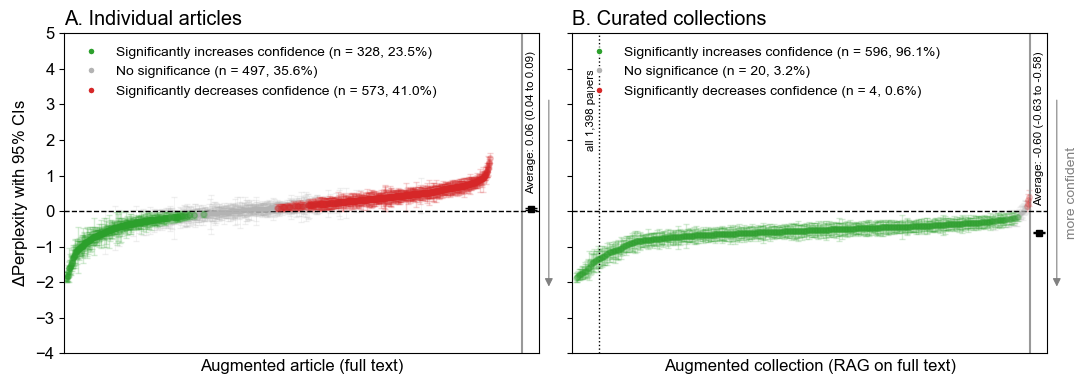

In [34]:
from matplotlib.patches import FancyArrowPatch

# 1) Compute per-predictor ΔRMSE and CIs
delta_art, ci_lo_art, ci_hi_art = compute_paper_deltas(
    df_base_ppl.T, df_individual_ppl,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

delta_coll, ci_lo_coll, ci_hi_coll = compute_paper_deltas(
    df_base_ppl.T, df_collection_ppl,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

# 2) Two subplots side by side with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

# ----- Left: individual articles -----
ax1 = axes[0]
ax1.set_ylim(-4, 5)
plot_delta_ppl_forest(delta_art, ci_lo_art, ci_hi_art, ax=ax1)
#ax1.set_ylim(-4, 6)
ax1.set_title("A. Individual articles", loc="left")

# Remove the arrow + "better prediction" label from the left panel
for txt in list(ax1.texts):
    if txt.get_text() == 'more confident':
        txt.remove()

for patch in list(ax1.patches):
    if isinstance(patch, FancyArrowPatch):
        patch.remove()

# Keep y-label on the left as is
ax1.set_xlabel("Augmented article (full text)")

# ----- Right: curated collections -----
ax2 = axes[1]
ax2.set_ylim(-4, 5)
plot_delta_ppl_forest(delta_coll, ci_lo_coll, ci_hi_coll, ax=ax2)
ax2.set_title("B. Curated collections", loc='left')
ax2.set_ylabel('')  # keep y-label only on left
ax2.set_xlabel("Augmented collection (RAG)")

# === Highlight the 'ALL' collection ===
# Find its original row index in df_collection_se
all_idx = df_collection_ppl.index.get_loc('ALL')

# Find its x-position after sorting by ΔRMSE (same sort as inside the plot function)
order_coll = np.argsort(delta_coll)
x_all = np.where(order_coll == all_idx)[0][0]

# Vertical line at that x, plus a small rotated label
ax2.axvline(x_all, color='black', linestyle=':', linewidth=1)

ymin, ymax = ax2.get_ylim()
ax2.text(
    x_all - 10,
    ymax - 1,                     # just below the top
    'all 1,398 papers',
    rotation=90,
    va='top',
    ha='center',
    fontsize='x-small'
)

# Share y-axis: remove duplicate y-label on the right
ax2.set_ylabel('')
ax2.set_xlabel("Augmented collection (RAG on full text)")

plt.tight_layout()
plt.show()

# Perplexity on Abstract

In [35]:
# --- Perplexity: abstract ---

df_base_ppl = pd.read_csv(base_dir + 'output/perplexity_baseline_GPT41.csv')
# Align Q1..Q20 to CONFIG_configId
df_base_ppl = align_se_df(df_base_ppl, base_index, config_ids, name='ppl_baseline_abstract')
df_base_ppl.index = ['baseline']

df_individual_ppl = align_se_df(
    pd.read_csv(base_dir + 'output/perplexity_individual_abstract.csv', index_col=0),
    base_index, config_ids, name='ppl_individual_abstract'
)
df_collection_ppl = align_se_df(
    pd.read_csv(base_dir + 'output/perplexity_collection_abstract.csv', index_col=0),
    base_index, config_ids, name='ppl_collection_abstract'
)

df_all_ppl = align_se_df(
    pd.read_csv(base_dir + 'output/perplexity_all_abstract.csv', index_col=0),
    base_index, config_ids, name='ppl_all_abstract'
)

# include the all-papers aggregate row
df_collection_ppl = pd.concat([df_collection_ppl, df_all_ppl])


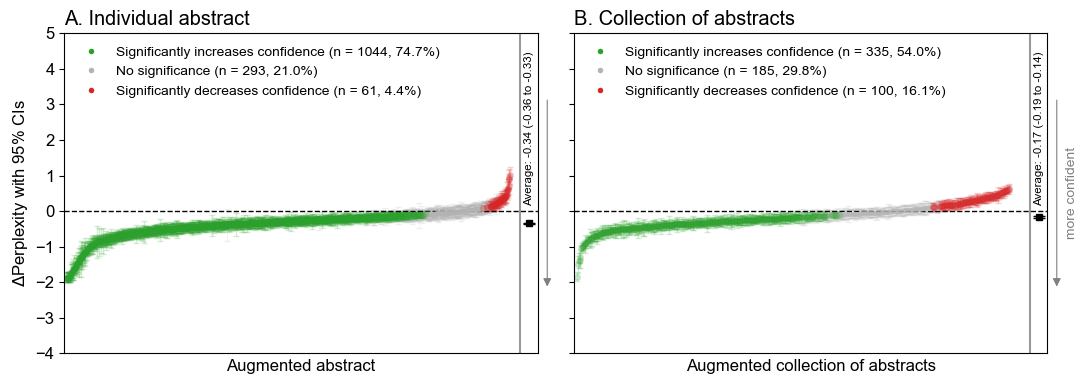

In [36]:
from matplotlib.patches import FancyArrowPatch

# 1) Compute per-predictor ΔRMSE and CIs
delta_art, ci_lo_art, ci_hi_art = compute_paper_deltas(
    df_base_ppl.T, df_individual_ppl,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

delta_coll, ci_lo_coll, ci_hi_coll = compute_paper_deltas(
    df_base_ppl.T, df_collection_ppl,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

# 2) Two subplots side by side with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

# ----- Left: individual articles -----
ax1 = axes[0]
ax1.set_ylim(-4, 5)
plot_delta_ppl_forest(delta_art, ci_lo_art, ci_hi_art, ax=ax1)
#ax1.set_ylim(-4, 6)
ax1.set_title("A. Individual abstract", loc="left")

# Remove the arrow + "better prediction" label from the left panel
for txt in list(ax1.texts):
    if txt.get_text() == 'more confident':
        txt.remove()

for patch in list(ax1.patches):
    if isinstance(patch, FancyArrowPatch):
        patch.remove()

# Keep y-label on the left as is
ax1.set_xlabel("Augmented abstract")

# ----- Right: curated collections -----
ax2 = axes[1]
ax2.set_ylim(-4, 5)
plot_delta_ppl_forest(delta_coll, ci_lo_coll, ci_hi_coll, ax=ax2)
ax2.set_title("B. Collection of abstracts", loc='left')
ax2.set_ylabel('')  # keep y-label only on left
ax2.set_xlabel("Augmented collection of abstracts")

# === Highlight the 'ALL' collection ===
# Find its original row index in df_collection_se
all_idx = df_collection_ppl.index.get_loc('ALL')

# Find its x-position after sorting by ΔRMSE (same sort as inside the plot function)
order_coll = np.argsort(delta_coll)
x_all = np.where(order_coll == all_idx)[0][0]

# Vertical line at that x, plus a small rotated label

# Share y-axis: remove duplicate y-label on the right
ax2.set_ylabel('')
ax2.set_xlabel("Augmented collection of abstracts")

plt.tight_layout()
plt.show()

# Perplexity on Report

In [37]:
# --- Perplexity: LLM summary ---

df_base_ppl = pd.read_csv(base_dir + 'output/perplexity_baseline_GPT41.csv')
# Align Q1..Q20 to CONFIG_configId
df_base_ppl = align_se_df(df_base_ppl, base_index, config_ids, name='ppl_baseline_report')
df_base_ppl.index = ['baseline']

df_individual_ppl = align_se_df(
    pd.read_csv(base_dir + 'output/perplexity_individual_report.csv', index_col=0),
    base_index, config_ids, name='ppl_individual_report'
)
df_collection_ppl = align_se_df(
    pd.read_csv(base_dir + 'output/perplexity_collection_report.csv', index_col=0),
    base_index, config_ids, name='ppl_collection_report'
)

df_all_ppl = align_se_df(
    pd.read_csv(base_dir + 'output/perplexity_all_report.csv', index_col=0),
    base_index, config_ids, name='ppl_all_report'
)

# For consistency with the plots, label the aggregate row
if len(df_all_ppl.index) == 1:
    df_all_ppl.index = ['ALL']

# include the all-papers aggregate row
df_collection_ppl = pd.concat([df_collection_ppl, df_all_ppl])


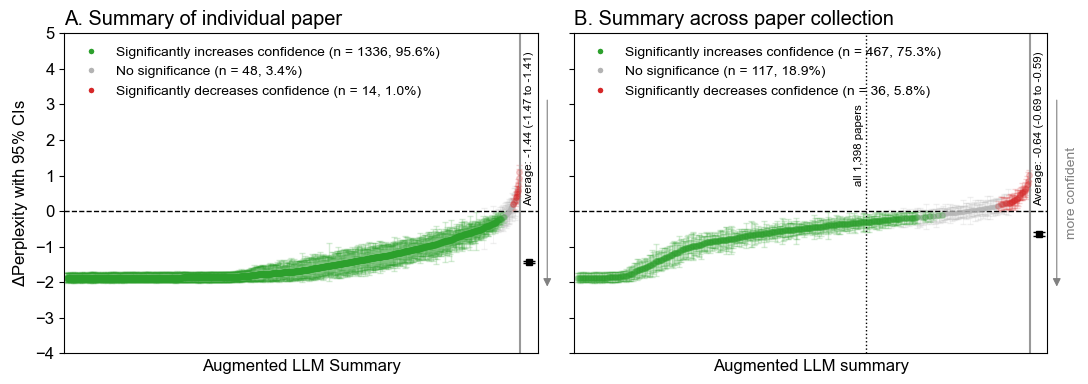

In [38]:
from matplotlib.patches import FancyArrowPatch

# 1) Compute per-predictor ΔRMSE and CIs
delta_art, ci_lo_art, ci_hi_art = compute_paper_deltas(
    df_base_ppl.T, df_individual_ppl,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

delta_coll, ci_lo_coll, ci_hi_coll = compute_paper_deltas(
    df_base_ppl.T, df_collection_ppl,
    baseline_col='baseline',
    n_boot=500, seed=42,
)

# 2) Two subplots side by side with shared y-axis
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

# ----- Left: individual articles -----
ax1 = axes[0]
ax1.set_ylim(-4, 5)
plot_delta_ppl_forest(delta_art, ci_lo_art, ci_hi_art, ax=ax1)
#ax1.set_ylim(-4, 6)
ax1.set_title("A. Summary of individual paper", loc="left")

# Remove the arrow + "better prediction" label from the left panel
for txt in list(ax1.texts):
    if txt.get_text() == 'more confident':
        txt.remove()

for patch in list(ax1.patches):
    if isinstance(patch, FancyArrowPatch):
        patch.remove()

# Keep y-label on the left as is
ax1.set_xlabel("Augmented LLM Summary")

# ----- Right: curated collections -----
ax2 = axes[1]
ax2.set_ylim(-4, 5)
plot_delta_ppl_forest(delta_coll, ci_lo_coll, ci_hi_coll, ax=ax2)
ax2.set_title("B. Summary across paper collection", loc='left')
ax2.set_ylabel('')  # keep y-label only on left
ax2.set_xlabel("Augmented collection of abstracts")

# === Highlight the 'ALL' collection ===
# Find its original row index in df_collection_se
all_idx = df_collection_ppl.index.get_loc('ALL')

# Find its x-position after sorting by ΔRMSE (same sort as inside the plot function)
order_coll = np.argsort(delta_coll)
x_all = np.where(order_coll == all_idx)[0][0]

# Vertical line at that x, plus a small rotated label
ax2.axvline(x_all, color='black', linestyle=':', linewidth=1)

ymin, ymax = ax2.get_ylim()
ax2.text(
    x_all - 10,
    ymax - 2,                     # just below the top
    'all 1,398 papers',
    rotation=90,
    va='top',
    ha='center',
    fontsize='x-small'
)

# Share y-axis: remove duplicate y-label on the right
ax2.set_ylabel('')
ax2.set_xlabel("Augmented LLM summary")

plt.tight_layout()
plt.show()